# Quoridor ML Training Pipeline

Minimal ML workflow: Data → EDA → Preprocessing → Training → Evaluation → Best Model

## 1. Imports & Setup

In [45]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import joblib

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix

sns.set_theme(style='whitegrid')
print('✓ Imports OK')

✓ Imports OK


## 2. Load Data

In [46]:
DATA_PATH = Path('ml_moves_dataset.csv')

df = pd.read_csv(DATA_PATH)

print(f'Shape: {df.shape}')
print(f'\nColumns: {list(df.columns)}')
print(f'\nLabel distribution:')
print(df['label'].value_counts())
print(f'\nMissing values:')
print(df.isnull().sum())

Shape: (34365, 23)

Columns: ['game_id', 'turn', 'game_phase', 'my_dist_before', 'opp_dist_before', 'dist_advantage_before', 'my_walls_before', 'opp_walls_before', 'wall_advantage_before', 'my_row_before', 'my_col_before', 'opp_row_before', 'opp_col_before', 'my_center_distance_before', 'opp_center_distance_before', 'is_pawn_move', 'is_wall_move', 'wall_is_horizontal', 'wall_is_vertical', 'pawn_move_distance', 'my_progress', 'opp_slowdown', 'label']

Label distribution:
label
 1    17332
-1    17033
Name: count, dtype: int64

Missing values:
game_id                       0
turn                          0
game_phase                    0
my_dist_before                0
opp_dist_before               0
dist_advantage_before         0
my_walls_before               0
opp_walls_before              0
wall_advantage_before         0
my_row_before                 0
my_col_before                 0
opp_row_before                0
opp_col_before                0
my_center_distance_before     0
opp_

## 3. EDA

Statistics by label:
      my_dist_before                                                   \
               count       mean       std  min  25%   50%   75%   max   
label                                                                   
-1           17033.0  12.216227  6.715651  1.0  7.0  10.0  17.0  41.0   
 1           17332.0   9.347854  5.285686  1.0  6.0   8.0  12.0  27.0   

      opp_dist_before             ... my_progress      opp_slowdown            \
                count       mean  ...         75%  max        count      mean   
label                             ...                                           
-1            17033.0   8.902307  ...         1.0  2.0      17033.0  0.469207   
 1            17332.0  11.516328  ...         1.0  2.0      17332.0  0.572525   

                                           
            std  min  25%  50%  75%   max  
label                                      
-1     0.964315  0.0  0.0  0.0  0.0  10.0  
 1     1.266512  0.0  0.0  0.0 

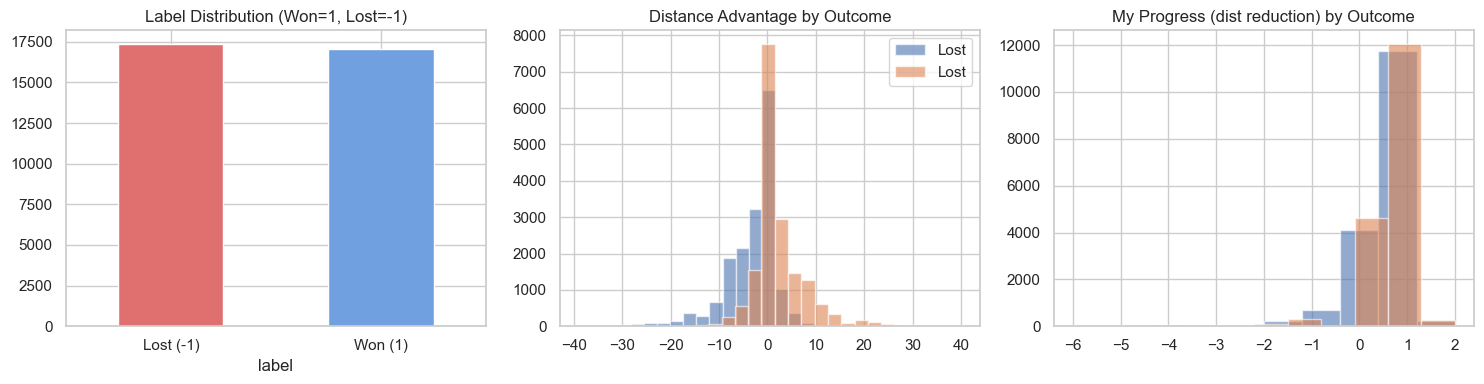


✓ EDA complete


In [47]:
print('Statistics by label:')
print(df.groupby('label')[['my_dist_before', 'opp_dist_before', 'my_progress', 'opp_slowdown']].describe())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Label distribution
df['label'].value_counts().plot(kind='bar', ax=axes[0], color=['#e07070', '#70a0e0'])
axes[0].set_title('Label Distribution (Won=1, Lost=-1)')
axes[0].set_xticklabels(['Lost (-1)', 'Won (1)'], rotation=0)

# Distance advantage distribution
df.groupby('label')['dist_advantage_before'].hist(ax=axes[1], alpha=0.6, bins=20, label=['Lost', 'Won'])
axes[1].set_title('Distance Advantage by Outcome')
axes[1].legend()

# Progress distribution
df.groupby('label')['my_progress'].hist(ax=axes[2], alpha=0.6, bins=10)
axes[2].set_title('My Progress (dist reduction) by Outcome')

plt.tight_layout()
plt.show()

print('\n✓ EDA complete')

## 4. Preprocessing

In [48]:
# Remove non-feature columns
EXCLUDE = ['game_id', 'turn', 'label']
feature_cols = [c for c in df.columns if c not in EXCLUDE]

print(f'Features ({len(feature_cols)}): {feature_cols}')
print(f'X shape: {df[feature_cols].shape}')

X = df[feature_cols].copy()
y = df['label'].copy()

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'\nTrain: {X_train.shape}')
print(f'Test: {X_test.shape}')
print(f'\nTrain label balance: {y_train.value_counts().to_dict()}')
print(f'Test label balance: {y_test.value_counts().to_dict()}')

Features (20): ['game_phase', 'my_dist_before', 'opp_dist_before', 'dist_advantage_before', 'my_walls_before', 'opp_walls_before', 'wall_advantage_before', 'my_row_before', 'my_col_before', 'opp_row_before', 'opp_col_before', 'my_center_distance_before', 'opp_center_distance_before', 'is_pawn_move', 'is_wall_move', 'wall_is_horizontal', 'wall_is_vertical', 'pawn_move_distance', 'my_progress', 'opp_slowdown']
X shape: (34365, 20)

Train: (27492, 20)
Test: (6873, 20)

Train label balance: {1: 13866, -1: 13626}
Test label balance: {1: 3466, -1: 3407}


## 5. Model Training & Evaluation

In [49]:
# Define models
models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'DecisionTree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
}

results = {}

for name, model in models.items():
    print(f'\n{name}...')
    
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    # Evaluate
    train_acc = accuracy_score(y_train, y_pred_train)
    test_acc = accuracy_score(y_test, y_pred_test)
    f1 = f1_score(y_test, y_pred_test)
    
    # AUC (convert labels to binary: -1→0, 1→1)
    y_test_binary = (y_test == 1).astype(int)
    y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else y_pred_test
    auc = roc_auc_score(y_test_binary, y_pred_proba) if hasattr(model, 'predict_proba') else 0.5
    
    results[name] = {
        'model': model,
        'train_acc': train_acc,
        'test_acc': test_acc,
        'f1': f1,
        'auc': auc,
    }
    
    print(f'  Train Acc: {train_acc:.4f}')
    print(f'  Test Acc:  {test_acc:.4f}')
    print(f'  F1 Score:  {f1:.4f}')
    print(f'  AUC:       {auc:.4f}')

print('\n✓ Training complete')


LogisticRegression...
  Train Acc: 0.7572
  Test Acc:  0.7550
  F1 Score:  0.7587
  AUC:       0.8333

DecisionTree...
  Train Acc: 0.8400
  Test Acc:  0.8359
  F1 Score:  0.8418
  AUC:       0.9306

RandomForest...
  Train Acc: 1.0000
  Test Acc:  0.9383
  F1 Score:  0.9389
  AUC:       0.9866

GradientBoosting...
  Train Acc: 0.8685
  Test Acc:  0.8661
  F1 Score:  0.8679
  AUC:       0.9540

✓ Training complete


## 6. Compare & Select Best Model

In [50]:
# Results summary
summary = pd.DataFrame([
    {
        'Model': name,
        'Train Acc': r['train_acc'],
        'Test Acc': r['test_acc'],
        'F1': r['f1'],
        'AUC': r['auc'],
    }
    for name, r in results.items()
])

print('\n=== Model Comparison ===')
print(summary.to_string(index=False))

# Best by AUC
best_name = summary.loc[summary['AUC'].idxmax(), 'Model']
best_model = results[best_name]['model']

print(f'\n✓ BEST MODEL: {best_name}')
print(f'  Test Accuracy: {results[best_name]["test_acc"]:.4f}')
print(f'  AUC: {results[best_name]["auc"]:.4f}')


=== Model Comparison ===
             Model  Train Acc  Test Acc       F1      AUC
LogisticRegression   0.757238  0.754983 0.758739 0.833333
      DecisionTree   0.839953  0.835880 0.841795 0.930611
      RandomForest   0.999964  0.938309 0.938887 0.986639
  GradientBoosting   0.868544  0.866143 0.867854 0.954010

✓ BEST MODEL: RandomForest
  Test Accuracy: 0.9383
  AUC: 0.9866


## 7. Best Model Details

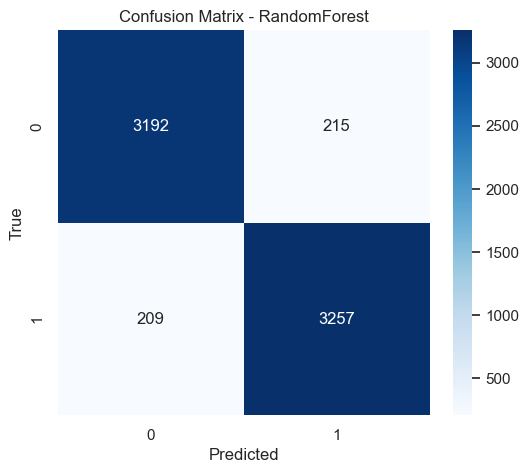


RandomForest - Classification Report:
              precision    recall  f1-score   support

   Lost (-1)       0.94      0.94      0.94      3407
     Won (1)       0.94      0.94      0.94      3466

    accuracy                           0.94      6873
   macro avg       0.94      0.94      0.94      6873
weighted avg       0.94      0.94      0.94      6873



In [51]:
# Confusion matrix
y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - {best_name}')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.show()

# Classification report
print(f'\n{best_name} - Classification Report:')
print(classification_report(y_test, y_pred_best, target_names=['Lost (-1)', 'Won (1)']))

## 8. Save Best Model

In [52]:
OUTPUT_PATH = Path('ml_selector.pkl')

# Save model
joblib.dump(best_model, OUTPUT_PATH)

print(f'✓ Model saved: {OUTPUT_PATH}')
print(f'  Type: {type(best_model).__name__}')
print(f'  Size: {OUTPUT_PATH.stat().st_size / 1024:.1f} KB')

# Verify
loaded = joblib.load(OUTPUT_PATH)
test_pred = loaded.predict(X_test[:5])
print(f'\n✓ Model loaded and working')
print(f'  Sample predictions: {test_pred}')

✓ Model saved: ml_selector.pkl
  Type: RandomForestClassifier
  Size: 33821.7 KB

✓ Model loaded and working
  Sample predictions: [ 1 -1 -1  1 -1]
